[1] "/fh/working/sun_w/sshen/MorPhiC/publication"

[1] "/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb"

Warning message:
“There were 21 warnings in `mutate()`.
The first warning was:
ℹ In argument: `has_final_threshold = purrr::map_lgl(file,
  de_table_has_final_threshold)`.
Caused by warning in `data.table::fread()`:
! Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.
ℹ Run `dplyr::last_dplyr_warnings()` to see the 20 remaining warnings.”


# A tibble: 1 × 3
  target_gene cohort  file_name            
  <chr>       <chr>   <chr>                
1 NKX2-1      NW_DMSO NKX2-1_DE_NW_DMSO.csv


Warning message in data.table::fread(file, data.table = FALSE):
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in data.table::fread(file, data.table = FALSE):
“Detected 17 column names but the data has 18 columns (i.e. invalid file). Added an extra default column name for the first column which is guessed to be row names or an index. Use setname

target_gene,cohort,n_tested_genes,n_de_genes
<fct>,<ord>,<int>,<int>
GCM1,JAX,21878,3198
GCM1,MSK,21878,2913
GCM1,UCSF,21878,4018
GCM1,NW,21878,1060
GCM1,NW_parent,21878,1982
NKX2-1,JAX,23284,1364
NKX2-1,MSK,23284,4113
NKX2-1,UCSF,23284,751
NKX2-1,NW,23284,24


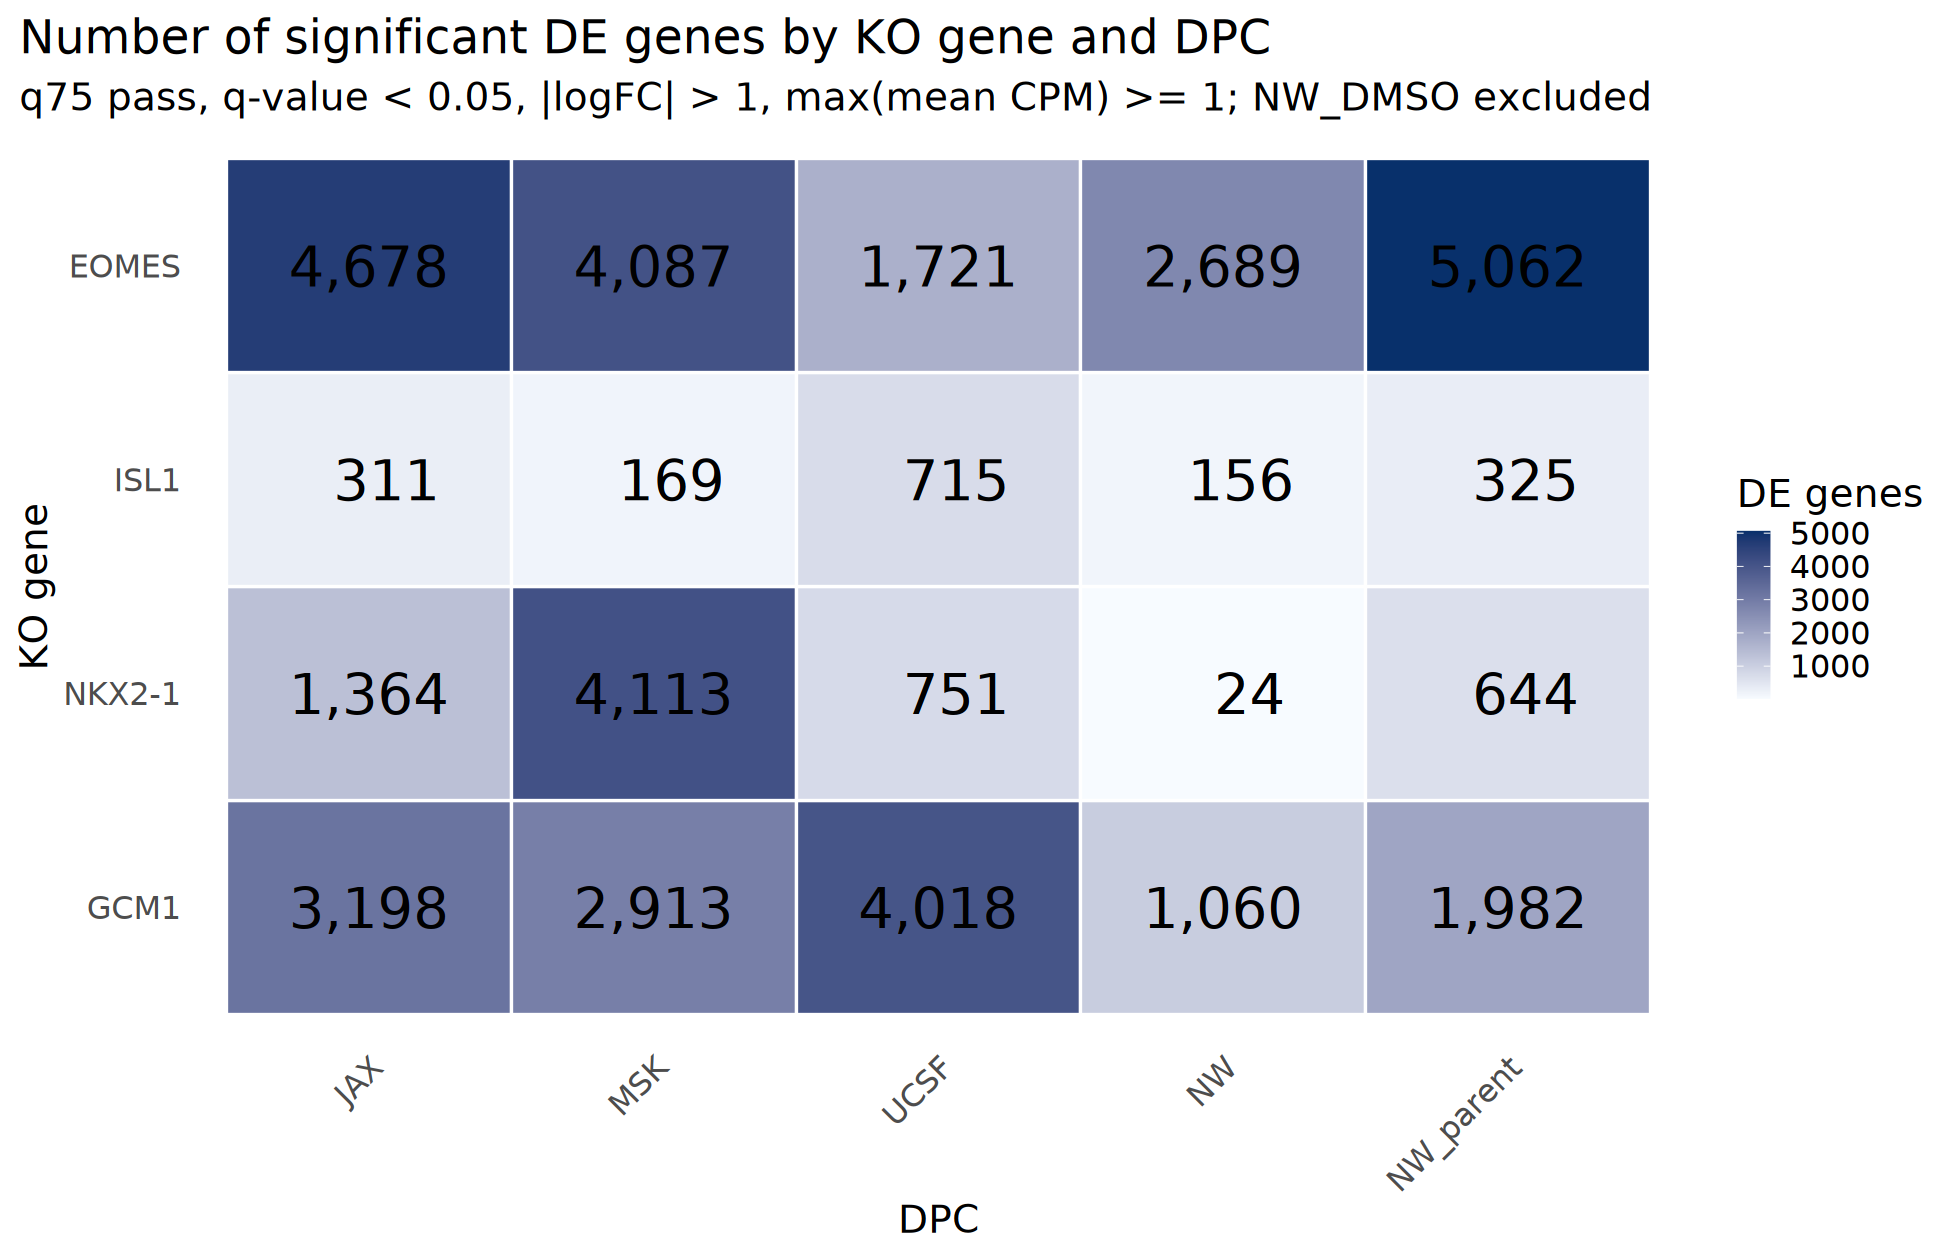

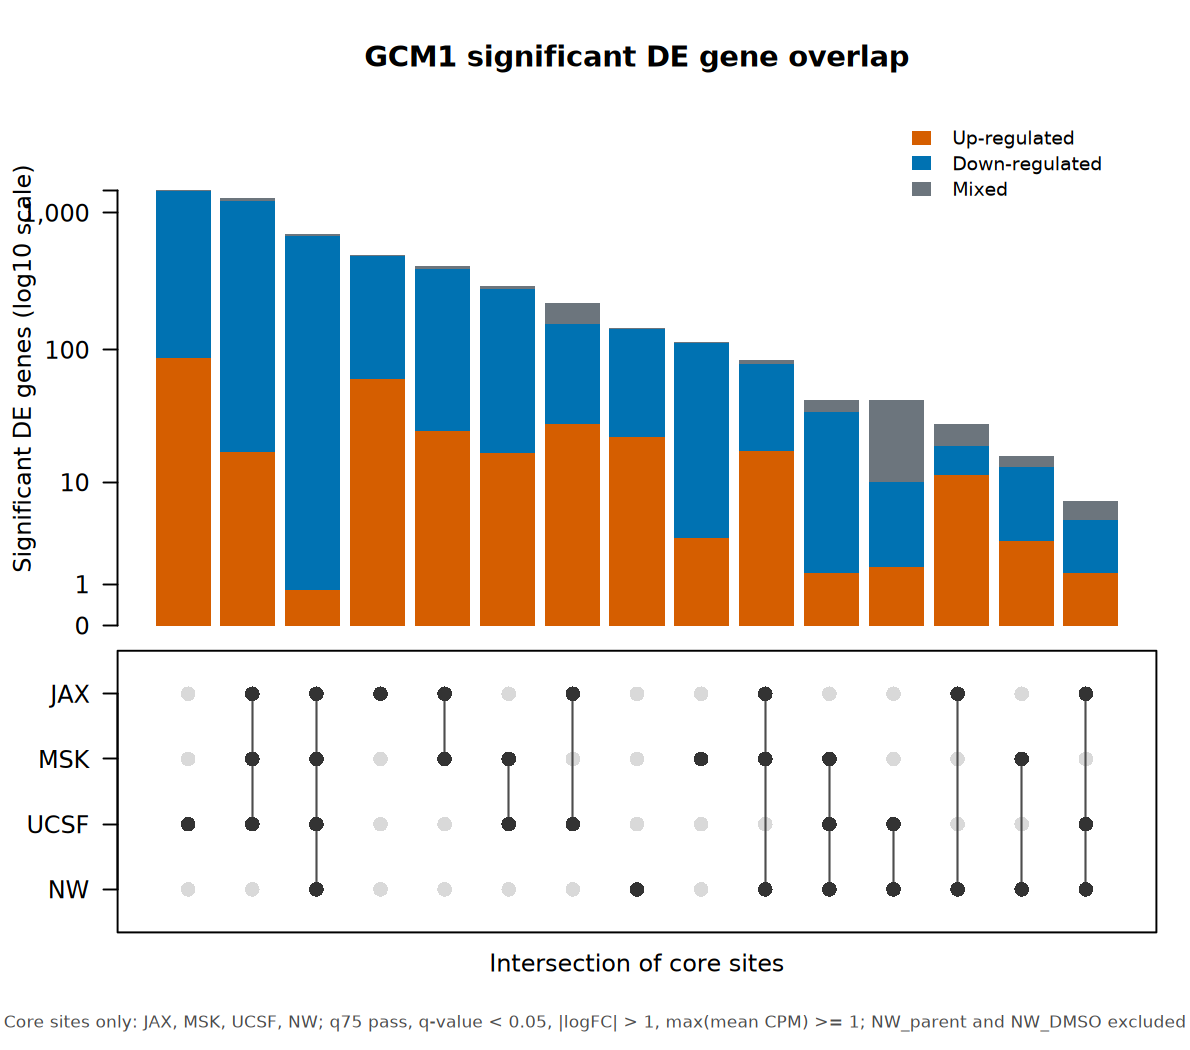

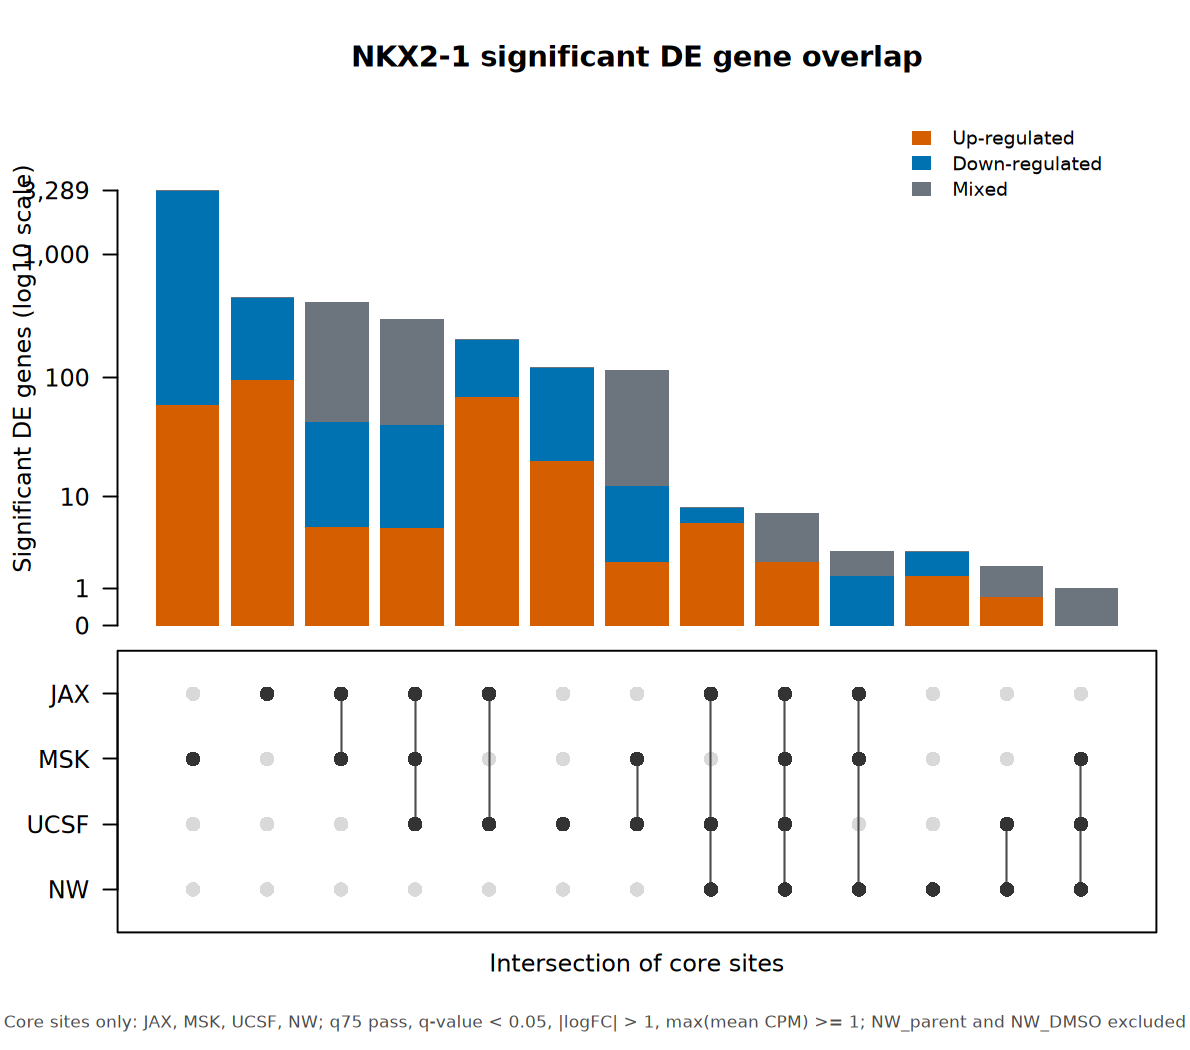

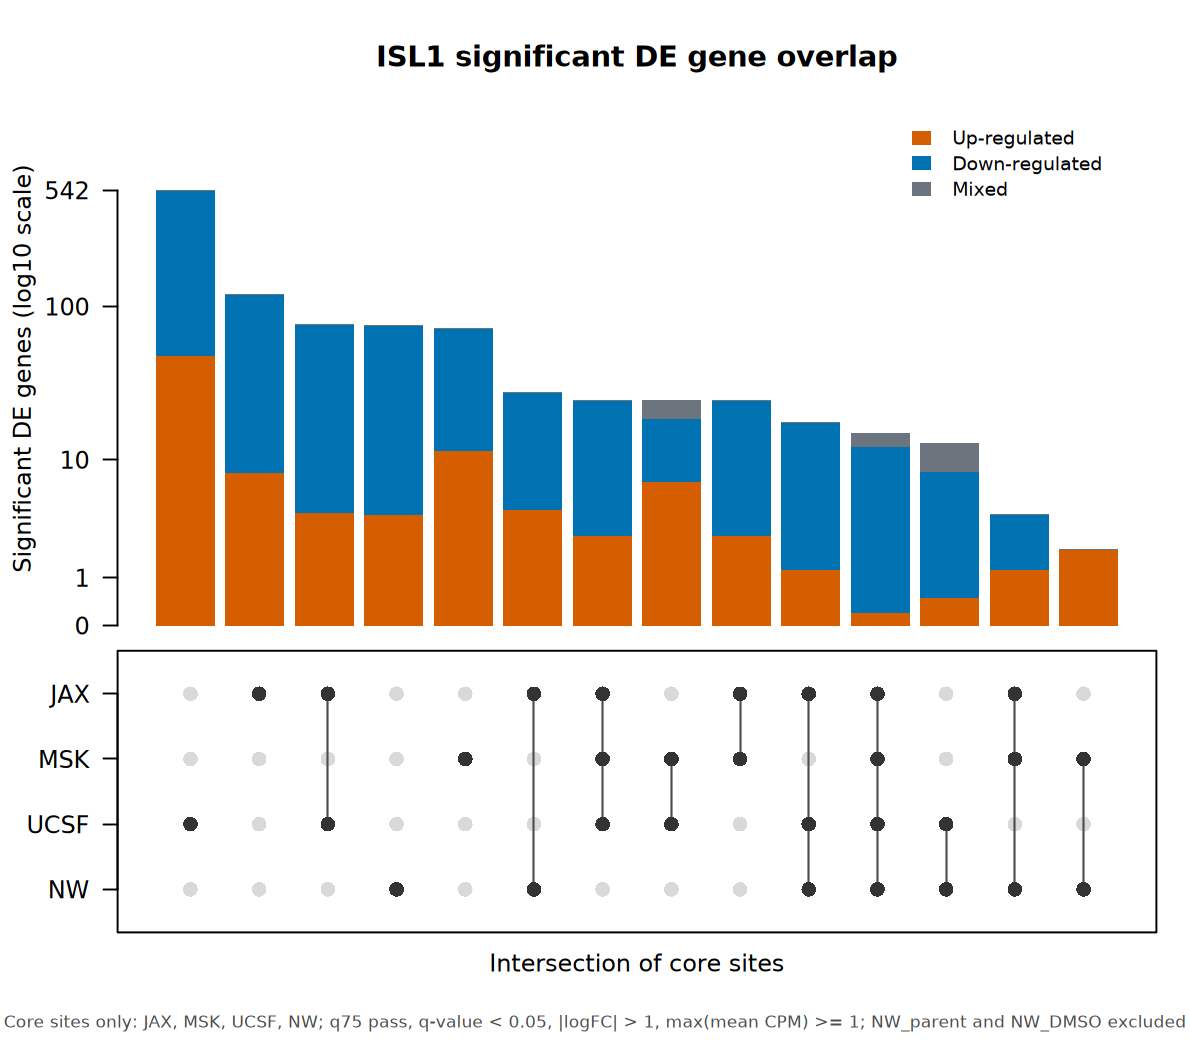

target_gene,figure,n_union,n_all_four_sites,n_JAX,n_MSK,n_UCSF,n_NW
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
GCM1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/DE_gene_overlap_upset/GCM1_DE_gene_overlap_core_sites_upset.png,5296,699,3198,2913,4018,1060
NKX2-1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/DE_gene_overlap_upset/NKX2_1_DE_gene_overlap_core_sites_upset.png,4894,7,1364,4113,751,24
ISL1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/DE_gene_overlap_upset/ISL1_DE_gene_overlap_core_sites_upset.png,1042,15,311,169,715,156
EOMES,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/DE_gene_overlap_upset/EOMES_DE_gene_overlap_core_sites_upset.png,6298,514,4678,4087,1721,2689


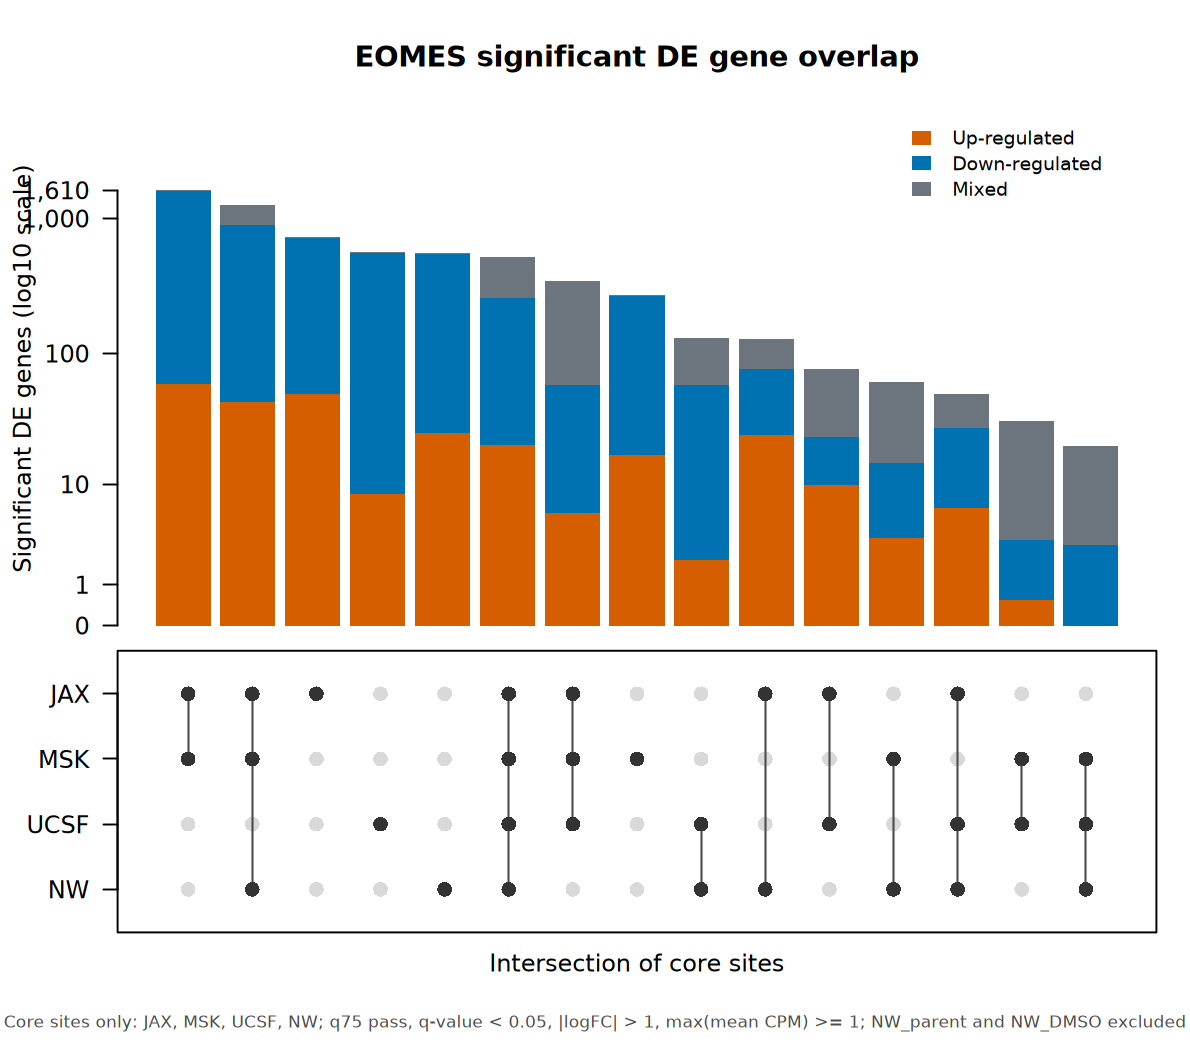

In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(ggplot2)
  library(ggrepel)
  library(stringr)
  library(tidyr)
  library(purrr)
  library(tibble)
})

theme_set(theme_classic(base_size = 12))

set_notebook_plot_size <- function(width = 14, height = 9, res = 140, pointsize = 12) {
  options(
    repr.plot.width = width,
    repr.plot.height = height,
    repr.plot.res = res,
    repr.plot.pointsize = pointsize
  )
  invisible(NULL)
}

set_notebook_plot_size()

target_genes <- c("GCM1", "NKX2-1", "ISL1", "EOMES")
core_institutions <- c("JAX", "MSK", "UCSF", "NW")
cohort_order <- c(core_institutions, "NW_parent", "NW_DMSO")

qvalue_cutoff <- 0.05
logfc_cutoff <- 1
max_mean_cpm_cutoff <- 1
de_threshold_label <- paste0(
  "q75 pass, q-value < ", qvalue_cutoff,
  ", |logFC| > ", logfc_cutoff,
  ", max(mean CPM) >= ", max_mean_cpm_cutoff
)

coerce_logical_column <- function(x) {
  if (is.logical(x)) {
    out <- x
  } else if (is.numeric(x) || is.integer(x)) {
    out <- !is.na(x) & x != 0
  } else {
    x_chr <- str_to_upper(str_trim(as.character(x)))
    out <- x_chr %in% c("TRUE", "T", "1", "YES", "Y")
    out[x_chr %in% c("FALSE", "F", "0", "NO", "N", "", "NA")] <- FALSE
  }
  out[is.na(out)] <- FALSE
  out
}

calculate_storey_qvalues <- function(p, label = "p-values") {
  if (!requireNamespace("qvalue", quietly = TRUE)) {
    stop("The qvalue package is required. Install it with BiocManager::install('qvalue').")
  }

  p <- as.numeric(p)
  keep_p <- is.finite(p) & p >= 0 & p <= 1
  qvals <- rep(NA_real_, length(p))
  if (any(keep_p)) {
    qvals[keep_p] <- qvalue::qvalue(p[keep_p])$qvalues
  }
  qvals
}

ensure_qvalue_column <- function(dt, file = "DE table") {
  if ("qvalue" %in% names(dt)) {
    return(dt)
  }
  if (!"P.Value" %in% names(dt)) {
    stop("Missing P.Value column in ", file, "; cannot calculate Storey q-values.")
  }

  dt$qvalue <- calculate_storey_qvalues(dt$P.Value, file)
  dt
}

ensure_de_threshold_column <- function(dt, file = "DE table") {
  if ("threshold" %in% names(dt)) {
    dt$threshold <- coerce_logical_column(dt$threshold)
    return(dt)
  }

  required_cols <- c("qvalue", "logFC", "q75_pass", "max_mean_CPM")
  missing_cols <- setdiff(required_cols, names(dt))
  if (length(missing_cols) > 0) {
    stop(
      "Missing threshold column in ", file,
      " and cannot reconstruct the final DE call without: ",
      paste(missing_cols, collapse = ", ")
    )
  }

  dt$threshold <- coerce_logical_column(dt$q75_pass) &
    !is.na(dt$qvalue) & dt$qvalue < qvalue_cutoff &
    is.finite(dt$logFC) & abs(dt$logFC) > logfc_cutoff &
    is.finite(dt$max_mean_CPM) & dt$max_mean_CPM >= max_mean_cpm_cutoff
  dt
}

de_table_has_final_threshold <- function(file) {
  "threshold" %in% names(data.table::fread(file, nrows = 0, data.table = FALSE))
}

print_each_volcano <- TRUE

personal_path <- Sys.getenv("MORPHIC_PERSONAL_PATH", unset = "/fh/working/sun_w/sshen/MorPhiC")
publication_dir <- file.path(personal_path, "publication")
figure_dir <- file.path(publication_dir, "DE_summary_ipynb")
volcano_figure_dir <- file.path(figure_dir, "volcano_plots")

stopifnot(dir.exists(publication_dir))
dir.create(volcano_figure_dir, recursive = TRUE, showWarnings = FALSE)

publication_dir
figure_dir


suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(ggplot2)
  library(limma)
  library(purrr)
  library(stringr)
  library(tibble)
  library(tidyr)
})

if (!exists("target_genes")) {
  target_genes <- c("GCM1", "NKX2-1", "ISL1", "EOMES")
}
if (!exists("core_institutions")) {
  core_institutions <- c("JAX", "MSK", "UCSF", "NW")
}
if (!exists("cohort_order")) {
  cohort_order <- c(core_institutions, "NW_parent", "NW_DMSO")
}
if (!exists("qvalue_cutoff")) {
  qvalue_cutoff <- 0.05
}
if (!exists("logfc_cutoff")) {
  logfc_cutoff <- 1
}
if (!exists("max_mean_cpm_cutoff")) {
  max_mean_cpm_cutoff <- 1
}
if (!exists("de_threshold_label")) {
  de_threshold_label <- paste0(
    "q75 pass, q-value < ", qvalue_cutoff,
    ", |logFC| > ", logfc_cutoff,
    ", max(mean CPM) >= ", max_mean_cpm_cutoff
  )
}
if (!exists("personal_path")) {
  personal_path <- Sys.getenv("MORPHIC_PERSONAL_PATH", unset = "/fh/working/sun_w/sshen/MorPhiC")
}
if (!exists("publication_dir")) {
  publication_dir <- file.path(personal_path, "publication")
}
if (!exists("figure_dir")) {
  figure_dir <- file.path(publication_dir, "DE_summary_ipynb")
}

if (!exists("coerce_logical_column")) {
  coerce_logical_column <- function(x) {
    if (is.logical(x)) {
      out <- x
    } else if (is.numeric(x) || is.integer(x)) {
      out <- !is.na(x) & x != 0
    } else {
      x_chr <- str_to_upper(str_trim(as.character(x)))
      out <- x_chr %in% c("TRUE", "T", "1", "YES", "Y")
      out[x_chr %in% c("FALSE", "F", "0", "NO", "N", "", "NA")] <- FALSE
    }
    out[is.na(out)] <- FALSE
    out
  }
}
if (!exists("ensure_qvalue_column")) {
  ensure_qvalue_column <- function(dt, file = "DE table") {
    if ("qvalue" %in% names(dt)) {
      return(dt)
    }
    if (!"P.Value" %in% names(dt)) {
      stop("Missing P.Value column in ", file, "; cannot calculate Storey q-values.")
    }
    if (!requireNamespace("qvalue", quietly = TRUE)) {
      stop("The qvalue package is required. Install it with BiocManager::install('qvalue').")
    }
    p <- as.numeric(dt$P.Value)
    keep_p <- is.finite(p) & p >= 0 & p <= 1
    dt$qvalue <- NA_real_
    if (any(keep_p)) {
      dt$qvalue[keep_p] <- qvalue::qvalue(p[keep_p])$qvalues
    }
    dt
  }
}
if (!exists("ensure_de_threshold_column")) {
  ensure_de_threshold_column <- function(dt, file = "DE table") {
    if ("threshold" %in% names(dt)) {
      dt$threshold <- coerce_logical_column(dt$threshold)
      return(dt)
    }
    required_cols <- c("qvalue", "logFC", "q75_pass", "max_mean_CPM")
    missing_cols <- setdiff(required_cols, names(dt))
    if (length(missing_cols) > 0) {
      stop(
        "Missing threshold column in ", file,
        " and cannot reconstruct the final DE call without: ",
        paste(missing_cols, collapse = ", ")
      )
    }
    dt$threshold <- coerce_logical_column(dt$q75_pass) &
      !is.na(dt$qvalue) & dt$qvalue < qvalue_cutoff &
      is.finite(dt$logFC) & abs(dt$logFC) > logfc_cutoff &
      is.finite(dt$max_mean_CPM) & dt$max_mean_CPM >= max_mean_cpm_cutoff
    dt
  }
}

if (!exists("de_table_has_final_threshold")) {
  de_table_has_final_threshold <- function(file) {
    "threshold" %in% names(data.table::fread(file, nrows = 0, data.table = FALSE))
  }
}

stopifnot(dir.exists(publication_dir))
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)

venn_cohorts <- core_institutions
heatmap_cohorts <- c(venn_cohorts, "NW_parent")
venn_figure_dir <- file.path(figure_dir, "DE_gene_overlap_upset")
dir.create(venn_figure_dir, recursive = TRUE, showWarnings = FALSE)

if (!exists("de_results")) {
  venn_de_file_paths <- list.files(
    publication_dir,
    pattern = "_DE_.*[.]csv$",
    full.names = TRUE
  )
  
  venn_de_file_index_all <- tibble(file = venn_de_file_paths) %>%
    mutate(
      file_name = basename(file),
      stem = tools::file_path_sans_ext(file_name),
      target_gene = sub("_DE_.*$", "", stem),
      cohort = sub("^.*_DE_", "", stem),
      dataset_id = paste(target_gene, cohort, sep = "_DE_"),
      has_final_threshold = purrr::map_lgl(file, de_table_has_final_threshold)
    ) %>%
    filter(target_gene %in% target_genes)
  
  stale_venn_de_files <- venn_de_file_index_all %>%
    filter(!has_final_threshold) %>%
    select(target_gene, cohort, file_name)
  print(stale_venn_de_files)
  
  venn_de_file_index <- venn_de_file_index_all %>%
    filter(has_final_threshold) %>%
    arrange(
      factor(target_gene, levels = target_genes),
      factor(cohort, levels = cohort_order),
      cohort
    )
  
  expected_venn_core <- tidyr::expand_grid(
    target_gene = target_genes,
    cohort = venn_cohorts
  )
  missing_venn_files <- anti_join(
    expected_venn_core,
    venn_de_file_index %>% distinct(target_gene, cohort),
    by = c("target_gene", "cohort")
  )
  if (nrow(missing_venn_files) > 0) {
    stop(
      "Missing core DE CSV files: ",
      paste(paste(missing_venn_files$target_gene, missing_venn_files$cohort, sep = ":"), collapse = ", ")
    )
  }
  
  read_de_table_for_venn <- function(file, target_gene, cohort) {
    dt <- data.table::fread(file, data.table = FALSE)
    expected_cols <- c("logFC", "AveExpr", "t", "P.Value", "B")
    
    if (!"gene_symbol" %in% names(dt)) {
      if ("V1" %in% names(dt)) {
        names(dt)[names(dt) == "V1"] <- "gene_symbol"
      } else if (ncol(dt) == length(expected_cols) + 1 && !(names(dt)[1] %in% expected_cols)) {
        names(dt)[1] <- "gene_symbol"
      } else {
        stop("Could not identify gene symbol column in ", file)
      }
    }
    
    missing_cols <- setdiff(c("gene_symbol", expected_cols), names(dt))
    if (length(missing_cols) > 0) {
      stop("Missing columns in ", file, ": ", paste(missing_cols, collapse = ", "))
    }
    
    dt <- ensure_qvalue_column(dt, file)
    dt <- ensure_de_threshold_column(dt, file)
    
    dt %>%
      transmute(
        target_gene = target_gene,
        cohort = cohort,
        dataset_id = paste(target_gene, cohort, sep = "_DE_"),
        gene_symbol = as.character(gene_symbol),
        logFC = as.numeric(logFC),
        qvalue = as.numeric(qvalue),
        q75_pass = if ("q75_pass" %in% names(dt)) coerce_logical_column(q75_pass) else NA,
        mean_CPM_WT = if ("mean_CPM_WT" %in% names(dt)) as.numeric(mean_CPM_WT) else NA_real_,
        mean_CPM_KO = if ("mean_CPM_KO" %in% names(dt)) as.numeric(mean_CPM_KO) else NA_real_,
        max_mean_CPM = if ("max_mean_CPM" %in% names(dt)) as.numeric(max_mean_CPM) else NA_real_,
        threshold = coerce_logical_column(threshold),
        is_significant = threshold
      )
  }
  
  de_results <- pmap_dfr(
    venn_de_file_index %>% select(file, target_gene, cohort),
    read_de_table_for_venn
  ) %>%
    mutate(
      target_gene = factor(target_gene, levels = target_genes),
      cohort = factor(cohort, levels = unique(c(cohort_order, sort(unique(as.character(cohort))))), ordered = TRUE)
    )
}

missing_venn_cohorts <- setdiff(venn_cohorts, as.character(unique(de_results$cohort)))
if (length(missing_venn_cohorts) > 0) {
  stop("Missing DE results for core cohorts: ", paste(missing_venn_cohorts, collapse = ", "))
}

venn_safe_name <- function(x) {
  str_replace_all(x, "[^A-Za-z0-9]+", "_") %>% str_replace_all("(^_|_$)", "")
}

make_core_site_de_membership <- function(gene1) {
  d <- de_results %>%
    mutate(
      target_gene = as.character(target_gene),
      cohort = as.character(cohort),
      gene_symbol = str_trim(gene_symbol)
    ) %>%
    filter(
      target_gene == gene1,
      cohort %in% venn_cohorts,
      is_significant,
      !is.na(gene_symbol),
      gene_symbol != ""
    ) %>%
    distinct(gene_symbol, cohort) %>%
    mutate(is_de = TRUE) %>%
    pivot_wider(
      names_from = cohort,
      values_from = is_de,
      values_fill = list(is_de = FALSE)
    )
  
  for (cohort1 in setdiff(venn_cohorts, names(d))) {
    d[[cohort1]] <- logical(nrow(d))
  }
  
  d %>%
    select(gene_symbol, all_of(venn_cohorts)) %>%
    arrange(gene_symbol)
}

core_site_de_membership <- map_dfr(target_genes, function(gene1) {
  make_core_site_de_membership(gene1) %>%
    mutate(target_gene = gene1, .before = gene_symbol)
})

core_site_membership_file <- file.path(venn_figure_dir, "DE_gene_overlap_core_site_membership.tsv")
data.table::fwrite(core_site_de_membership, core_site_membership_file, sep = "	")

core_site_de_counts <- de_results %>%
  mutate(
    target_gene = as.character(target_gene),
    cohort = as.character(cohort),
    gene_symbol = str_trim(gene_symbol)
  ) %>%
  filter(
    target_gene %in% target_genes,
    cohort %in% heatmap_cohorts,
    !is.na(gene_symbol),
    gene_symbol != ""
  ) %>%
  group_by(target_gene, cohort) %>%
  summarise(
    n_tested_genes = n_distinct(gene_symbol),
    n_de_genes = n_distinct(gene_symbol[is_significant]),
    .groups = "drop"
  ) %>%
  complete(
    target_gene = target_genes,
    cohort = heatmap_cohorts,
    fill = list(n_tested_genes = 0L, n_de_genes = 0L)
  ) %>%
  mutate(
    target_gene = factor(target_gene, levels = target_genes),
    cohort = factor(cohort, levels = heatmap_cohorts, ordered = TRUE)
  ) %>%
  arrange(target_gene, cohort)

core_site_de_counts_file <- file.path(venn_figure_dir, "DE_gene_counts_by_KO_and_DPC.tsv")
data.table::fwrite(core_site_de_counts, core_site_de_counts_file, sep = "	")

core_site_de_count_heatmap <- ggplot(core_site_de_counts, aes(x = cohort, y = target_gene, fill = n_de_genes)) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(aes(label = format(n_de_genes, big.mark = ",", scientific = FALSE)), size = 10) +
  scale_fill_gradient(low = "#F7FBFF", high = "#08306B") +
  labs(
    x = "DPC",
    y = "KO gene",
    fill = "DE genes",
    title = "Number of significant DE genes by KO gene and DPC",
    subtitle = paste0(de_threshold_label, "; NW_DMSO excluded")
  ) +
  theme_minimal(base_size = 20) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title.position = "plot"
  )

core_site_de_count_heatmap_file <- file.path(venn_figure_dir, "DE_gene_counts_by_KO_and_DPC_heatmap.png")
ggsave(
  filename = core_site_de_count_heatmap_file,
  plot = core_site_de_count_heatmap,
  width = 7,
  height = 4.5,
  device = "png",
  dpi = 300,
  bg = "white"
)

core_site_de_counts
print(core_site_de_count_heatmap)

regulation_classes <- c("up", "down", "mixed")
regulation_class_labels <- c(
  up = "Up-regulated",
  down = "Down-regulated",
  mixed = "Mixed"
)
regulation_class_colors <- c(
  up = "#D55E00",
  down = "#0072B2",
  mixed = "#6C757D"
)

make_core_site_upset_counts <- function(gene1) {
  direction_by_site <- de_results %>%
    mutate(
      target_gene = as.character(target_gene),
      cohort = as.character(cohort),
      gene_symbol = str_trim(gene_symbol)
    ) %>%
    filter(
      target_gene == gene1,
      cohort %in% venn_cohorts,
      is_significant,
      !is.na(gene_symbol),
      gene_symbol != "",
      !is.na(logFC),
      is.finite(logFC)
    ) %>%
    group_by(gene_symbol, cohort) %>%
    summarise(logFC = mean(logFC), .groups = "drop") %>%
    mutate(direction = if_else(logFC >= 0, "up", "down"))
  
  if (nrow(direction_by_site) == 0) {
    return(tibble(
      intersection = character(),
      n_genes = integer(),
      degree = integer(),
      n_up = integer(),
      n_down = integer(),
      n_mixed = integer()
    ))
  }
  
  direction_by_site %>%
    group_by(gene_symbol) %>%
    summarise(
      intersection = paste(as.integer(venn_cohorts %in% cohort), collapse = ""),
      regulation_class = if_else(n_distinct(direction) == 1, first(direction), "mixed"),
      .groups = "drop"
    ) %>%
    mutate(degree = str_count(intersection, "1")) %>%
    count(intersection, degree, regulation_class, name = "n_class_genes") %>%
    group_by(intersection, degree) %>%
    complete(regulation_class = regulation_classes, fill = list(n_class_genes = 0L)) %>%
    ungroup() %>%
    pivot_wider(
      names_from = regulation_class,
      values_from = n_class_genes,
      names_prefix = "n_",
      values_fill = list(n_class_genes = 0L)
    ) %>%
    mutate(
      across(all_of(paste0("n_", regulation_classes)), ~ as.integer(replace_na(.x, 0L))),
      n_genes = as.integer(n_up + n_down + n_mixed)
    ) %>%
    select(intersection, n_genes, degree, n_up, n_down, n_mixed) %>%
    arrange(desc(n_genes), desc(degree), intersection)
}

draw_core_site_de_upset <- function(gene1) {
  upset_counts <- make_core_site_upset_counts(gene1)
  title_text <- paste0(gene1, " significant DE gene overlap")
  note_text <- paste0(
    "Core sites only: ", paste(venn_cohorts, collapse = ", "),
    "; ", de_threshold_label,
    "; NW_parent and NW_DMSO excluded"
  )
  
  old_par <- par(no.readonly = TRUE)
  on.exit(par(old_par), add = TRUE)
  
  if (nrow(upset_counts) == 0) {
    plot.new()
    title(main = title_text)
    text(0.5, 0.5, "No significant DE genes in the core sites")
    mtext(note_text, side = 1, line = 0.5, cex = 0.72, col = "grey30")
    return(invisible(upset_counts))
  }
  
  membership_mat <- do.call(rbind, strsplit(upset_counts$intersection, "", fixed = TRUE)) == "1"
  colnames(membership_mat) <- venn_cohorts
  
  layout(matrix(c(1, 2), ncol = 1), heights = c(3.3, 1.8))
  par(mar = c(0.5, 4.2, 4.0, 1.2), oma = c(2.2, 0, 0, 0))
  bar_heights <- t(as.matrix(upset_counts[, paste0("n_", regulation_classes)]))
  rownames(bar_heights) <- regulation_classes
  total_counts <- colSums(bar_heights)
  log_total_counts <- log10(total_counts + 1)
  bar_heights_log <- sweep(bar_heights, 2, pmax(total_counts, 1), "/")
  bar_heights_log <- sweep(bar_heights_log, 2, log_total_counts, "*")
  rownames(bar_heights_log) <- regulation_classes
  max_count <- max(total_counts)
  y_tick_counts <- if (max_count <= 10) {
    0:max_count
  } else {
    ticks <- unique(c(0, 1, 10^seq(1, floor(log10(max_count)))))
    if (tail(ticks, 1) < max_count) ticks <- c(ticks, max_count)
    ticks
  }
  bar_centers <- barplot(
    bar_heights_log,
    names.arg = rep("", ncol(bar_heights_log)),
    col = regulation_class_colors[rownames(bar_heights_log)],
    border = NA,
    ylim = c(0, max(log_total_counts) * 1.18),
    yaxt = "n",
    ylab = "Significant DE genes (log10 scale)",
    main = title_text
  )
  axis(
    2,
    at = log10(y_tick_counts + 1),
    labels = format(y_tick_counts, big.mark = ",", scientific = FALSE),
    las = 1
  )
  legend(
    "topright",
    legend = regulation_class_labels[rownames(bar_heights_log)],
    fill = regulation_class_colors[rownames(bar_heights_log)],
    border = NA,
    bty = "n",
    cex = 0.78
  )
  
  cohort_y <- rev(seq_along(venn_cohorts))
  par(mar = c(2.0, 4.2, 0.4, 1.2))
  plot(
    NA,
    xlim = range(bar_centers) + c(-0.6, 0.6),
    ylim = c(0.5, length(venn_cohorts) + 0.5),
    xlab = "",
    ylab = "",
    xaxt = "n",
    yaxt = "n"
  )
  axis(2, at = cohort_y, labels = venn_cohorts, las = 1)
  mtext("Intersection of core sites", side = 1, line = 0.5)
  
  for (i in seq_along(bar_centers)) {
    points(rep(bar_centers[i], length(cohort_y)), cohort_y, pch = 16, col = "grey85", cex = 1.3)
    included_y <- cohort_y[membership_mat[i, ]]
    if (length(included_y) > 1) {
      segments(bar_centers[i], min(included_y), bar_centers[i], max(included_y), lwd = 1.1, col = "grey30")
    }
    points(rep(bar_centers[i], length(included_y)), included_y, pch = 16, col = "grey20", cex = 1.3)
  }
  mtext(note_text, side = 1, outer = TRUE, line = 0.5, cex = 0.72, col = "grey30")
  invisible(upset_counts)
}

save_core_site_de_upset <- function(gene1, out_file) {
  grDevices::png(
    filename = out_file,
    width = 2200,
    height = 2200,
    res = 300,
    bg = "white"
  )
  tryCatch(
    draw_core_site_de_upset(gene1),
    finally = grDevices::dev.off()
  )
  invisible(out_file)
}

summarise_core_site_de_overlap <- function(gene1, out_file) {
  d <- core_site_de_membership %>% filter(target_gene == gene1)
  site_counts <- d %>%
    summarise(across(all_of(venn_cohorts), ~ sum(.x, na.rm = TRUE))) %>%
    rename_with(~ paste0("n_", .x))
  
  tibble(
    target_gene = gene1,
    figure = out_file,
    n_union = nrow(d),
    n_all_four_sites = sum(rowSums(as.matrix(d[, venn_cohorts])) == length(venn_cohorts))
  ) %>%
    bind_cols(site_counts)
}

if (exists("set_notebook_plot_size")) {
  set_notebook_plot_size(width = 8.5, height = 7.5, res = 140, pointsize = 12)
}

upset_index <- map_dfr(target_genes, function(gene1) {
  out_file <- file.path(
    venn_figure_dir,
    paste0(venn_safe_name(gene1), "_DE_gene_overlap_core_sites_upset.png")
  )
  save_core_site_de_upset(gene1, out_file)
  draw_core_site_de_upset(gene1)
  summarise_core_site_de_overlap(gene1, out_file)
})

if (exists("set_notebook_plot_size")) {
  set_notebook_plot_size()
}

data.table::fwrite(upset_index, file.path(venn_figure_dir, "DE_gene_overlap_core_site_upset_index.tsv"), sep = "\t")
upset_index

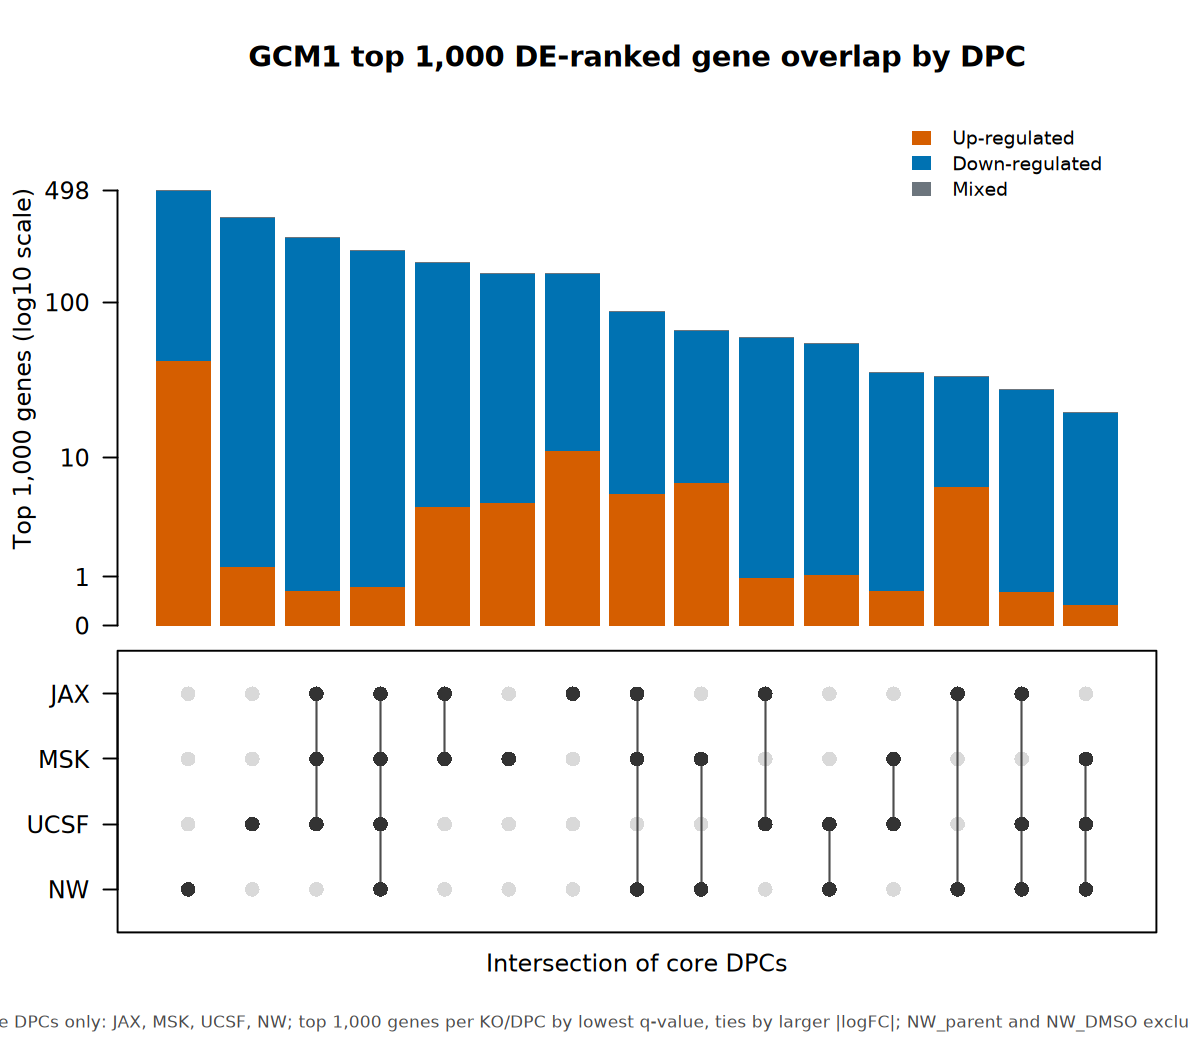

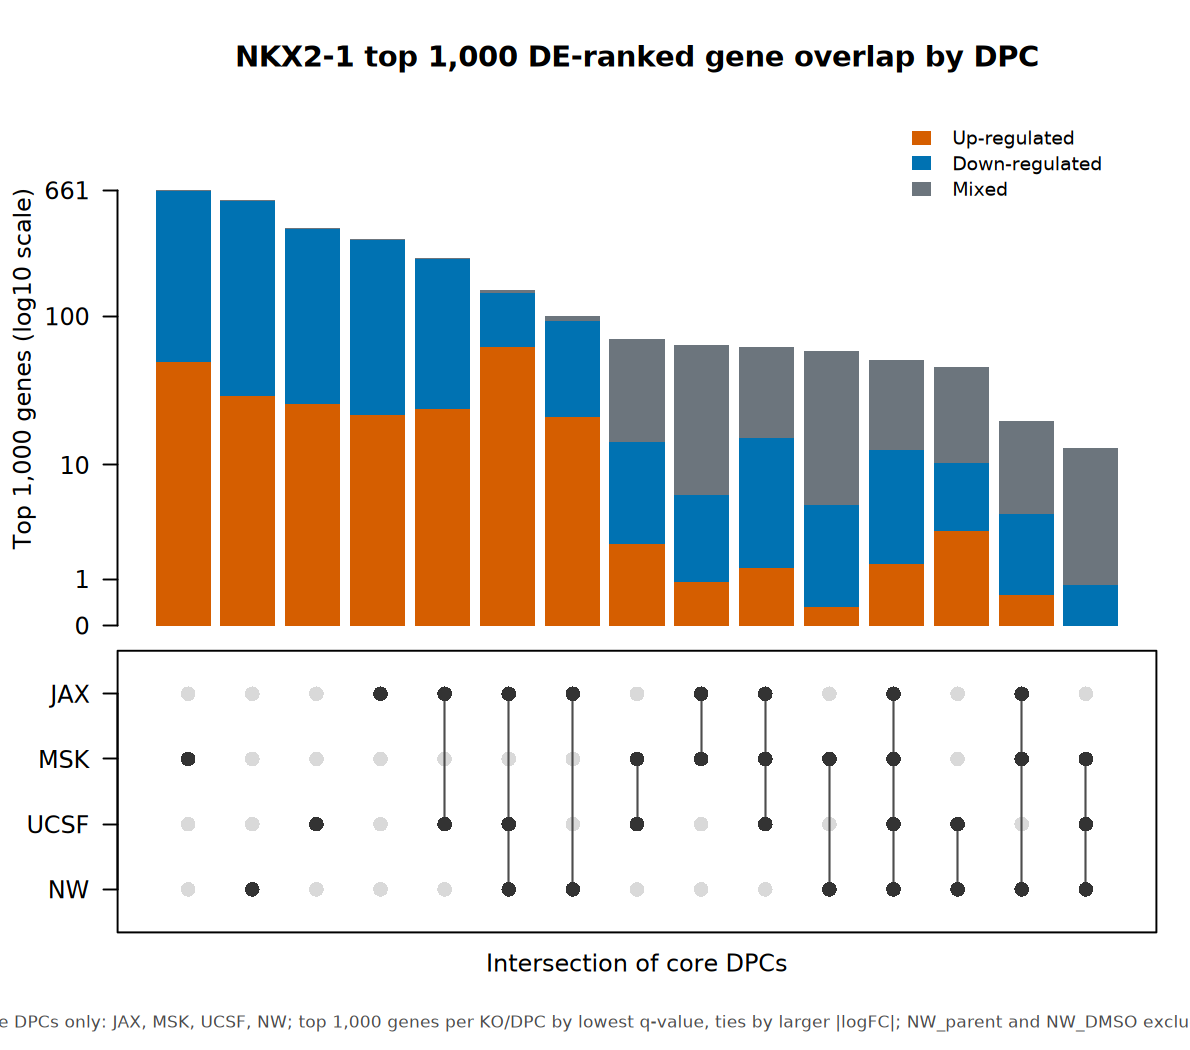

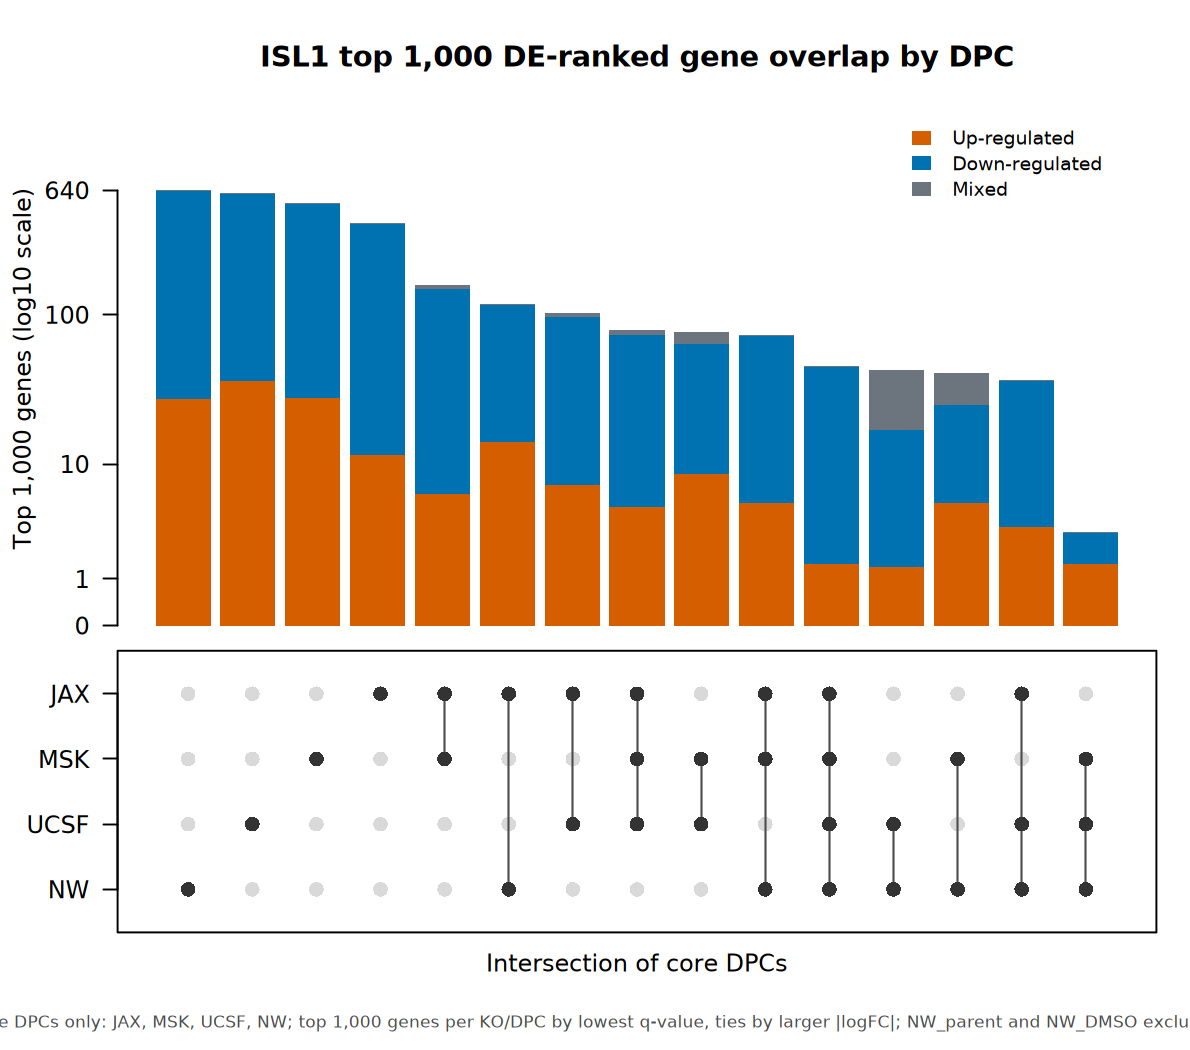

target_gene,figure,n_union,n_all_core_dpcs,n_JAX,n_MSK,n_UCSF,n_NW
<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>
GCM1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/top1000_DE_gene_overlap_upset/GCM1_top1000_DE_gene_overlap_by_DPC_upset.png,2164,211,1000,1000,1000,1000
NKX2-1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/top1000_DE_gene_overlap_upset/NKX2_1_top1000_DE_gene_overlap_by_DPC_upset.png,2784,51,1000,1000,1000,1000
ISL1,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/top1000_DE_gene_overlap_upset/ISL1_top1000_DE_gene_overlap_by_DPC_upset.png,2944,46,1000,1000,1000,1000
EOMES,/fh/working/sun_w/sshen/MorPhiC/publication/DE_summary_ipynb/top1000_DE_gene_overlap_upset/EOMES_top1000_DE_gene_overlap_by_DPC_upset.png,2547,77,1000,1000,1000,1000


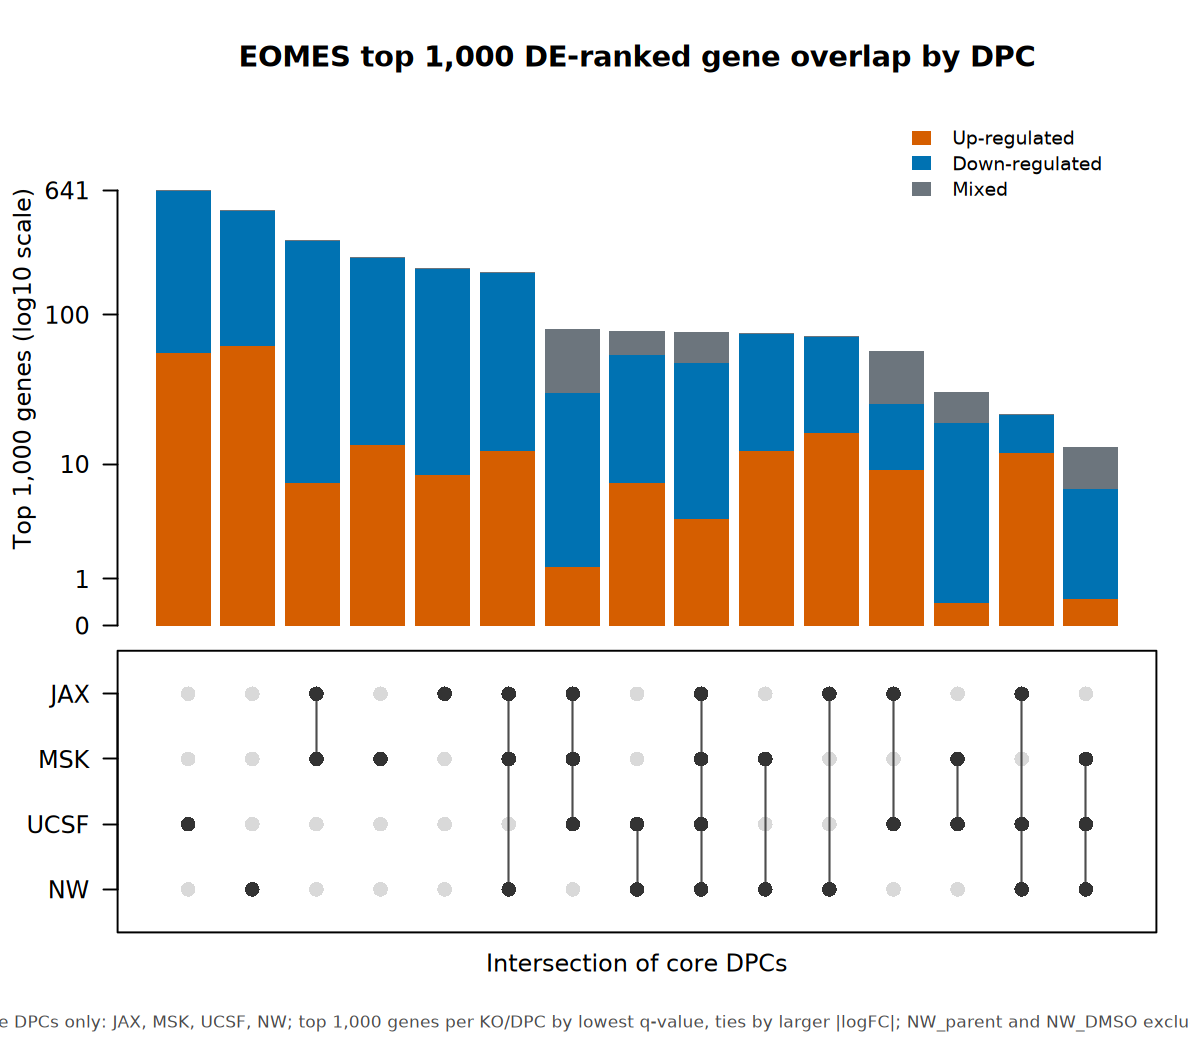

In [3]:
if (!exists("de_results")) {
  stop("Run the DE result loading / significant-overlap cell before the top-1000 overlap cell.")
}

top_n_de_genes <- 1000L
top_n_label <- format(top_n_de_genes, big.mark = ",", scientific = FALSE)
top1000_rank_label <- paste0(
  "top ", top_n_label,
  " genes per KO/DPC by lowest q-value, ties by larger |logFC|"
)

top1000_figure_dir <- file.path(figure_dir, "top1000_DE_gene_overlap_upset")
dir.create(top1000_figure_dir, recursive = TRUE, showWarnings = FALSE)

if (!exists("venn_safe_name")) {
  venn_safe_name <- function(x) {
    str_replace_all(x, "[^A-Za-z0-9]+", "_") %>% str_replace_all("(^_|_$)", "")
  }
}
if (!exists("regulation_classes")) {
  regulation_classes <- c("up", "down", "mixed")
}
if (!exists("regulation_class_labels")) {
  regulation_class_labels <- c(
    up = "Up-regulated",
    down = "Down-regulated",
    mixed = "Mixed"
  )
}
if (!exists("regulation_class_colors")) {
  regulation_class_colors <- c(
    up = "#D55E00",
    down = "#0072B2",
    mixed = "#6C757D"
  )
}

top1000_dpc_levels <- venn_cohorts

rankable_de_results <- de_results %>%
  mutate(
    target_gene = as.character(target_gene),
    cohort = as.character(cohort),
    gene_symbol = str_trim(gene_symbol),
    logFC = as.numeric(logFC),
    qvalue = as.numeric(qvalue),
    max_mean_CPM = as.numeric(max_mean_CPM),
    abs_logFC = abs(logFC),
    rank_abs_logFC = if_else(is.finite(abs_logFC), abs_logFC, -Inf),
    rank_max_mean_CPM = if_else(is.finite(max_mean_CPM), max_mean_CPM, -Inf)
  ) %>%
  filter(
    target_gene %in% target_genes,
    cohort %in% top1000_dpc_levels,
    !is.na(gene_symbol),
    gene_symbol != "",
    is.finite(qvalue)
  ) %>%
  group_by(target_gene, cohort, gene_symbol) %>%
  arrange(qvalue, desc(rank_abs_logFC), desc(rank_max_mean_CPM), .by_group = TRUE) %>%
  slice_head(n = 1) %>%
  ungroup()

top1000_de_results <- rankable_de_results %>%
  group_by(target_gene, cohort) %>%
  arrange(qvalue, desc(rank_abs_logFC), desc(rank_max_mean_CPM), gene_symbol, .by_group = TRUE) %>%
  mutate(top_rank = row_number(), is_top1000 = TRUE) %>%
  filter(top_rank <= top_n_de_genes) %>%
  ungroup()

make_top1000_dpc_membership <- function(gene1) {
  d <- top1000_de_results %>%
    transmute(
      target_gene = as.character(target_gene),
      cohort = as.character(cohort),
      gene_symbol = str_trim(gene_symbol)
    ) %>%
    filter(
      target_gene == gene1,
      cohort %in% top1000_dpc_levels,
      !is.na(gene_symbol),
      gene_symbol != ""
    ) %>%
    distinct(gene_symbol, cohort) %>%
    mutate(is_top1000 = TRUE) %>%
    pivot_wider(
      names_from = cohort,
      values_from = is_top1000,
      values_fill = list(is_top1000 = FALSE)
    )
  
  for (cohort1 in setdiff(top1000_dpc_levels, names(d))) {
    d[[cohort1]] <- logical(nrow(d))
  }
  
  d %>%
    select(gene_symbol, all_of(top1000_dpc_levels)) %>%
    arrange(gene_symbol)
}

make_top1000_dpc_upset_counts <- function(gene1) {
  direction_by_dpc <- top1000_de_results %>%
    transmute(
      target_gene = as.character(target_gene),
      cohort = as.character(cohort),
      gene_symbol = str_trim(gene_symbol),
      logFC = as.numeric(logFC)
    ) %>%
    filter(
      target_gene == gene1,
      cohort %in% top1000_dpc_levels,
      !is.na(gene_symbol),
      gene_symbol != "",
      !is.na(logFC),
      is.finite(logFC)
    ) %>%
    group_by(gene_symbol, cohort) %>%
    summarise(logFC = mean(logFC), .groups = "drop") %>%
    mutate(direction = if_else(logFC >= 0, "up", "down"))
  
  if (nrow(direction_by_dpc) == 0) {
    return(tibble(
      intersection = character(),
      n_genes = integer(),
      degree = integer(),
      n_up = integer(),
      n_down = integer(),
      n_mixed = integer()
    ))
  }
  
  direction_by_dpc %>%
    group_by(gene_symbol) %>%
    summarise(
      intersection = paste(as.integer(top1000_dpc_levels %in% cohort), collapse = ""),
      regulation_class = if_else(n_distinct(direction) == 1, first(direction), "mixed"),
      .groups = "drop"
    ) %>%
    mutate(degree = str_count(intersection, "1")) %>%
    count(intersection, degree, regulation_class, name = "n_class_genes") %>%
    group_by(intersection, degree) %>%
    complete(regulation_class = regulation_classes, fill = list(n_class_genes = 0L)) %>%
    ungroup() %>%
    pivot_wider(
      names_from = regulation_class,
      values_from = n_class_genes,
      names_prefix = "n_",
      values_fill = list(n_class_genes = 0L)
    ) %>%
    mutate(
      across(all_of(paste0("n_", regulation_classes)), ~ as.integer(replace_na(.x, 0L))),
      n_genes = as.integer(n_up + n_down + n_mixed)
    ) %>%
    select(intersection, n_genes, degree, n_up, n_down, n_mixed) %>%
    arrange(desc(n_genes), desc(degree), intersection)
}

draw_top1000_dpc_upset <- function(gene1) {
  upset_counts <- make_top1000_dpc_upset_counts(gene1)
  title_text <- paste0(gene1, " top ", top_n_label, " DE-ranked gene overlap by DPC")
  note_text <- paste0(
    "Core DPCs only: ", paste(top1000_dpc_levels, collapse = ", "),
    "; ", top1000_rank_label,
    "; NW_parent and NW_DMSO excluded"
  )
  
  old_par <- par(no.readonly = TRUE)
  on.exit(par(old_par), add = TRUE)
  
  if (nrow(upset_counts) == 0) {
    plot.new()
    title(main = title_text)
    text(0.5, 0.5, paste0("No ", top1000_rank_label))
    mtext(note_text, side = 1, line = 0.5, cex = 0.72, col = "grey30")
    return(invisible(upset_counts))
  }
  
  membership_mat <- do.call(rbind, strsplit(upset_counts$intersection, "", fixed = TRUE)) == "1"
  colnames(membership_mat) <- top1000_dpc_levels
  
  layout(matrix(c(1, 2), ncol = 1), heights = c(3.3, 1.8))
  par(mar = c(0.5, 4.2, 4.0, 1.2), oma = c(2.2, 0, 0, 0))
  bar_heights <- t(as.matrix(upset_counts[, paste0("n_", regulation_classes)]))
  rownames(bar_heights) <- regulation_classes
  total_counts <- colSums(bar_heights)
  log_total_counts <- log10(total_counts + 1)
  bar_heights_log <- sweep(bar_heights, 2, pmax(total_counts, 1), "/")
  bar_heights_log <- sweep(bar_heights_log, 2, log_total_counts, "*")
  rownames(bar_heights_log) <- regulation_classes
  max_count <- max(total_counts)
  y_tick_counts <- if (max_count <= 10) {
    0:max_count
  } else {
    ticks <- unique(c(0, 1, 10^seq(1, floor(log10(max_count)))))
    if (tail(ticks, 1) < max_count) ticks <- c(ticks, max_count)
    ticks
  }
  bar_centers <- barplot(
    bar_heights_log,
    names.arg = rep("", ncol(bar_heights_log)),
    col = regulation_class_colors[rownames(bar_heights_log)],
    border = NA,
    ylim = c(0, max(log_total_counts) * 1.18),
    yaxt = "n",
    ylab = paste0("Top ", top_n_label, " genes (log10 scale)"),
    main = title_text
  )
  axis(
    2,
    at = log10(y_tick_counts + 1),
    labels = format(y_tick_counts, big.mark = ",", scientific = FALSE),
    las = 1
  )
  legend(
    "topright",
    legend = regulation_class_labels[rownames(bar_heights_log)],
    fill = regulation_class_colors[rownames(bar_heights_log)],
    border = NA,
    bty = "n",
    cex = 0.78
  )
  
  dpc_y <- rev(seq_along(top1000_dpc_levels))
  par(mar = c(2.0, 4.2, 0.4, 1.2))
  plot(
    NA,
    xlim = range(bar_centers) + c(-0.6, 0.6),
    ylim = c(0.5, length(top1000_dpc_levels) + 0.5),
    xlab = "",
    ylab = "",
    xaxt = "n",
    yaxt = "n"
  )
  axis(2, at = dpc_y, labels = top1000_dpc_levels, las = 1)
  mtext("Intersection of core DPCs", side = 1, line = 0.5)
  
  for (i in seq_along(bar_centers)) {
    points(rep(bar_centers[i], length(dpc_y)), dpc_y, pch = 16, col = "grey85", cex = 1.3)
    included_y <- dpc_y[membership_mat[i, ]]
    if (length(included_y) > 1) {
      segments(bar_centers[i], min(included_y), bar_centers[i], max(included_y), lwd = 1.1, col = "grey30")
    }
    points(rep(bar_centers[i], length(included_y)), included_y, pch = 16, col = "grey20", cex = 1.3)
  }
  mtext(note_text, side = 1, outer = TRUE, line = 0.5, cex = 0.72, col = "grey30")
  invisible(upset_counts)
}

save_top1000_dpc_upset <- function(gene1, out_file) {
  grDevices::png(
    filename = out_file,
    width = 2200,
    height = 2200,
    res = 300,
    bg = "white"
  )
  tryCatch(
    draw_top1000_dpc_upset(gene1),
    finally = grDevices::dev.off()
  )
  invisible(out_file)
}

top1000_by_ko_membership <- map_dfr(target_genes, function(gene1) {
  make_top1000_dpc_membership(gene1) %>%
    mutate(target_gene = gene1, .before = gene_symbol)
})
top1000_by_ko_membership_file <- file.path(top1000_figure_dir, "top1000_DE_gene_overlap_by_KO_membership.tsv")
data.table::fwrite(top1000_by_ko_membership, top1000_by_ko_membership_file, sep = "\t")

summarise_top1000_dpc_overlap <- function(gene1, out_file) {
  d <- top1000_by_ko_membership %>% filter(target_gene == gene1)
  dpc_counts <- d %>%
    summarise(across(all_of(top1000_dpc_levels), ~ sum(.x, na.rm = TRUE))) %>%
    rename_with(~ paste0("n_", .x))
  
  tibble(
    target_gene = gene1,
    figure = out_file,
    n_union = nrow(d),
    n_all_core_dpcs = sum(rowSums(as.matrix(d[, top1000_dpc_levels, drop = FALSE])) == length(top1000_dpc_levels))
  ) %>%
    bind_cols(dpc_counts)
}

if (exists("set_notebook_plot_size")) {
  set_notebook_plot_size(width = 8.5, height = 7.5, res = 140, pointsize = 12)
}

top1000_by_ko_upset_index <- map_dfr(target_genes, function(gene1) {
  out_file <- file.path(
    top1000_figure_dir,
    paste0(venn_safe_name(gene1), "_top1000_DE_gene_overlap_by_DPC_upset.png")
  )
  save_top1000_dpc_upset(gene1, out_file)
  draw_top1000_dpc_upset(gene1)
  summarise_top1000_dpc_overlap(gene1, out_file)
})

if (exists("set_notebook_plot_size")) {
  set_notebook_plot_size()
}

data.table::fwrite(
  top1000_by_ko_upset_index,
  file.path(top1000_figure_dir, "top1000_DE_gene_overlap_by_KO_upset_index.tsv"),
  sep = "\t"
)
top1000_by_ko_upset_index
